In [9]:
from __future__ import annotations

import random
from pathlib import Path
from torchvision.utils import make_grid
import math
import matplotlib.pyplot as plt
import torch.nn as nn

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path.cwd()
CELEBA_ROOT = PROJECT_ROOT / "celebadata"

ATTR_CSV_PATH = CELEBA_ROOT / "list_attr_celeba.csv"
PARTITION_CSV_PATH = CELEBA_ROOT / "list_eval_partition.csv"

PREPARED_ROOT = PROJECT_ROOT / "celebadata_prepared"
PREPARED_IMAGES_DIR = PREPARED_ROOT / "images_128_mtcnn"

IMAGE_SIZE = 128
Z_DIM = 128
BATCH_SIZE = 64
NUM_WORKERS = 4
LR = 2e-4
BETAS = (0.5, 0.999)

MAX_SAMPLES = 124000

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)


DEVICE: cuda


In [10]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split


attr_df = pd.read_csv(ATTR_CSV_PATH)
part_df = pd.read_csv(PARTITION_CSV_PATH)

tmp = part_df.merge(attr_df[["image_id", "Male"]], on="image_id", how="inner")
tmp["prepared_path"] = tmp["image_id"].apply(lambda x: str(PREPARED_IMAGES_DIR / x))
tmp["exists"] = tmp["prepared_path"].map(lambda p: Path(p).exists())

prepared_df = tmp[tmp["exists"]].copy().reset_index(drop=True)
prepared_df["male"] = (prepared_df["Male"] == 1).astype(int)

print("Total prepared:", len(prepared_df))


Total prepared: 119212


In [11]:
tr_val, te = train_test_split(
    prepared_df, test_size=0.10, random_state=SEED, stratify=prepared_df["male"]
)
tr, va = train_test_split(
    tr_val, test_size=0.10/0.90, random_state=SEED, stratify=tr_val["male"]
)

tr["split_name"] = "train"
va["split_name"] = "val"
te["split_name"] = "test"

prepared_df = pd.concat([tr, va, te], ignore_index=True)
prepared_df = prepared_df[["prepared_path", "split_name", "male"]]

print(prepared_df["split_name"].value_counts())
print("Total:", len(prepared_df))


split_name
train    95368
val      11922
test     11922
Name: count, dtype: int64
Total: 119212


In [12]:

class CelebaPreparedDataset(Dataset):
    def __init__(self, df: pd.DataFrame, split_name: str):
        self.df = df[df["split_name"] == split_name].reset_index(drop=True).copy()
        self.tfm = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = self.tfm(Image.open(row["prepared_path"]).convert("RGB"))
        y = int(row["male"])
        return x, y

train_ds = CelebaPreparedDataset(prepared_df, "train")
val_ds = CelebaPreparedDataset(prepared_df, "val")
test_ds = CelebaPreparedDataset(prepared_df, "test")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(len(train_ds), len(val_ds), len(test_ds))


95368 11922 11922


In [13]:
torch.autograd.set_detect_anomaly(True, check_nan=False)



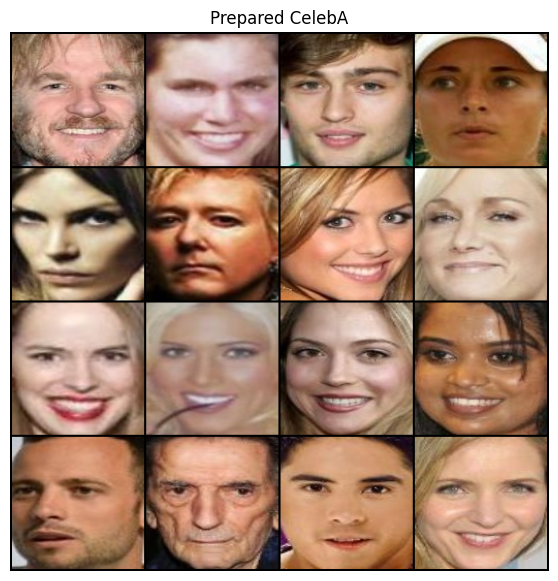

In [ ]:
def show_batch(loader, n=16, title="batch"):
    batch = next(iter(loader))
    x = batch[0] if isinstance(batch, (tuple, list)) else batch
    x = x[:n].cpu()

    grid = make_grid((x * 0.5 + 0.5).clamp(0, 1), nrow=int(math.sqrt(n)))
    plt.figure(figsize=(7, 7))
    plt.title(title)
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis("off")
    plt.show()


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True)

show_batch(train_loader, n=16, title="Prepared CelebA")

In [ ]:
def weights_init(m):
    name = m.__class__.__name__
    if "Conv" in name or "Linear" in name:
        if getattr(m, "weight", None) is not None:
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        if getattr(m, "bias", None) is not None:
            nn.init.constant_(m.bias.data, 0.0)
    elif "BatchNorm" in name:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0.0)

class ConditionalGenerator(nn.Module):
    def __init__(self, z_dim=128, n_cls=2, emb_dim=16):
        super().__init__()
        self.emb = nn.Embedding(n_cls, emb_dim)
        self.backbone = Generator(z_dim + emb_dim).net

    def forward(self, z, y):
        y = y.view(-1).long()
        assert z.size(0) == y.size(0), f"G: z={z.size(0)} y={y.size(0)}"
        e = self.emb(y).unsqueeze(-1).unsqueeze(-1)
        return self.backbone(torch.cat([z, e], dim=1))

class Generator(nn.Module):
    def __init__(self, z_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False), nn.BatchNorm2d(512), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, 1, 0, bias=False), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).view(-1)


class ConditionalDiscriminator(nn.Module):
    def __init__(self, n_cls=2, hw=128):
        super().__init__()
        self.emb = nn.Embedding(n_cls, hw * hw)
        self.first = nn.Sequential(
            nn.Conv2d(4, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
        )
        tail = list(Discriminator().net.children())[1:]
        self.tail = nn.Sequential(*tail)

    def forward(self, x, y):
        y = y.view(-1).long()
        assert x.size(0) == y.size(0), f"D: x={x.size(0)} y={y.size(0)}"
        ymap = self.emb(y).view(-1, 1, x.size(2), x.size(3))
        h = self.first(torch.cat([x, ymap], dim=1))
        out = self.tail(h)
        if out.ndim == 4:
            out = out.mean(dim=(2, 3))
        return out.view(-1)


class ConditionalDiscriminator(nn.Module):
    def __init__(self, n_cls=2):
        super().__init__()
        self.emb = nn.Embedding(n_cls, 1)
        self.first = nn.Sequential(
            nn.Conv2d(4, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=False),
        )
        tail = list(Discriminator().net.children())[1:]
        self.tail = nn.Sequential(*tail)

    def forward(self, x, y):
        y = y.view(-1).long()
        assert x.size(0) == y.size(0), f"x batch={x.size(0)}, y batch={y.size(0)}"

        ymap = self.emb(y).view(-1, 1, 1, 1).expand(-1, 1, x.size(2), x.size(3))
        h = self.first(torch.cat([x, ymap], dim=1))
        out = self.tail(h)
        if out.ndim == 4:
            out = out.mean(dim=(2, 3))
        return out.view(-1)



def train_cgan(G, D, loader, epochs=5):
    G, D = G.to(DEVICE), D.to(DEVICE)
    G.apply(weights_init)
    D.apply(weights_init)

    opt_g = torch.optim.Adam(G.parameters(), lr=LR, betas=BETAS)
    opt_d = torch.optim.Adam(D.parameters(), lr=LR, betas=BETAS)
    bce = nn.BCELoss()

    hist = {"g_loss": [], "d_loss": []}

    for ep in range(1, epochs + 1):
        g_losses, d_losses = [], []

        for real, y in tqdm(loader, desc=f"cGAN {ep}/{epochs}"):
            real, y = real.to(DEVICE), y.to(DEVICE)
            bsz = real.size(0)

            opt_d.zero_grad(set_to_none=True)

            pred_real = D(real, y)
            loss_real = bce(pred_real, torch.ones_like(pred_real))

            z = torch.randn(bsz, Z_DIM, 1, 1, device=DEVICE)
            fake = G(z, y).detach()
            pred_fake = D(fake, y)
            loss_fake = bce(pred_fake, torch.zeros_like(pred_fake))

            d_loss = loss_real + loss_fake
            d_loss.backward()
            opt_d.step()

            opt_g.zero_grad(set_to_none=True)

            z = torch.randn(bsz, Z_DIM, 1, 1, device=DEVICE)
            fake = G(z, y)
            pred_fake_g = D(fake, y)
            g_loss = bce(pred_fake_g, torch.ones_like(pred_fake_g))

            g_loss.backward()
            opt_g.step()

            g_losses.append(g_loss.item())
            d_losses.append(d_loss.item())

        hist["g_loss"].append(float(np.mean(g_losses)))
        hist["d_loss"].append(float(np.mean(d_losses)))

    return G, D, hist


real, y = next(iter(train_loader))
real, y = real.to(DEVICE), y.to(DEVICE).view(-1).long()

pred = ConditionalDiscriminator().to(DEVICE)(real, y)
print("pred shape:", pred.shape, "bsz:", real.size(0))

CKPT_DIR = PROJECT_ROOT / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

CGAN_G_PATH = CKPT_DIR / "cgan_G.pth"
CGAN_D_PATH = CKPT_DIR / "cgan_D.pth"

cgan_G = ConditionalGenerator(Z_DIM).to(DEVICE)
cgan_D = ConditionalDiscriminator().to(DEVICE)

if CGAN_G_PATH.exists() and CGAN_D_PATH.exists():
    cgan_G.load_state_dict(torch.load(CGAN_G_PATH, map_location=DEVICE))
    cgan_D.load_state_dict(torch.load(CGAN_D_PATH, map_location=DEVICE))
    cgan_G.eval()
    cgan_D.eval()
else:
    cgan_G, cgan_D, cgan_hist = train_cgan(cgan_G, cgan_D, train_loader, epochs=8)
    torch.save(cgan_G.state_dict(), CGAN_G_PATH)
    torch.save(cgan_D.state_dict(), CGAN_D_PATH)
    print("Saved:", CGAN_G_PATH, CGAN_D_PATH)



pred shape: torch.Size([64]) bsz: 64


In [19]:
@torch.no_grad()
def collect_real(loader, n=512):
    xs = []
    total = 0

    for x, _ in loader:
        xs.append(x)
        total += x.size(0)
        if total >= n:
            break

    x = torch.cat(xs, dim=0)[:n]
    return (x * 0.5 + 0.5).clamp(0, 1)
@torch.no_grad()
def collect_fake(G, n=512, conditional=False, label=0):
    G.eval()
    out = []
    total = 0

    while total < n:
        b = min(128, n - total)
        z = torch.randn(b, Z_DIM, 1, 1, device=DEVICE)

        if conditional:
            y = torch.full((b,), label, dtype=torch.long, device=DEVICE)
            x = G(z, y)
        else:
            x = G(z)

        x = (x * 0.5 + 0.5).clamp(0, 1).cpu()
        out.append(x)
        total += b

    return torch.cat(out, dim=0)[:n]


In [ ]:
def train_gan(G, D, loader, epochs=5):
    G, D = G.to(DEVICE), D.to(DEVICE)
    G.apply(weights_init)
    D.apply(weights_init)

    opt_g = torch.optim.Adam(G.parameters(), lr=LR, betas=BETAS)
    opt_d = torch.optim.Adam(D.parameters(), lr=LR, betas=BETAS)
    bce = nn.BCELoss()

    hist = {"g_loss": [], "d_loss": []}

    for ep in range(1, epochs + 1):
        g_losses, d_losses = [], []

        for real, _ in tqdm(loader, desc=f"GAN {ep}/{epochs}"):
            real = real.to(DEVICE)
            bsz = real.size(0)

            opt_d.zero_grad(set_to_none=True)

            pred_real = D(real)
            loss_real = bce(pred_real, torch.ones_like(pred_real))

            z = torch.randn(bsz, Z_DIM, 1, 1, device=DEVICE)
            fake = G(z).detach()
            pred_fake = D(fake)
            loss_fake = bce(pred_fake, torch.zeros_like(pred_fake))

            d_loss = loss_real + loss_fake
            d_loss.backward()
            opt_d.step()

            opt_g.zero_grad(set_to_none=True)

            z = torch.randn(bsz, Z_DIM, 1, 1, device=DEVICE)
            fake = G(z)
            pred_fake = D(fake)

            g_loss = bce(pred_fake, torch.ones_like(pred_fake))
            g_loss.backward()
            opt_g.step()

            g_losses.append(g_loss.item())
            d_losses.append(d_loss.item())

        hist["g_loss"].append(np.mean(g_losses))
        hist["d_loss"].append(np.mean(d_losses))

    return G, D, hist

In [ ]:
gan_G, gan_D, gan_hist = train_gan(
    Generator(Z_DIM),
    Discriminator(),
    train_loader,
    epochs=8
)

GAN 1/8:   0%|          | 0/1490 [00:00<?, ?it/s]

GAN 2/8:   0%|          | 0/1490 [00:00<?, ?it/s]

GAN 3/8:   0%|          | 0/1490 [00:00<?, ?it/s]

GAN 4/8:   0%|          | 0/1490 [00:00<?, ?it/s]

GAN 5/8:   0%|          | 0/1490 [00:00<?, ?it/s]

GAN 6/8:   0%|          | 0/1490 [00:00<?, ?it/s]

GAN 7/8:   0%|          | 0/1490 [00:00<?, ?it/s]

GAN 8/8:   0%|          | 0/1490 [00:00<?, ?it/s]

In [ ]:
def plot_losses(hist, title="Loss curves"):
    plt.figure(figsize=(8, 5))
    plt.plot(hist["g_loss"], label="Generator")
    plt.plot(hist["d_loss"], label="Discriminator")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

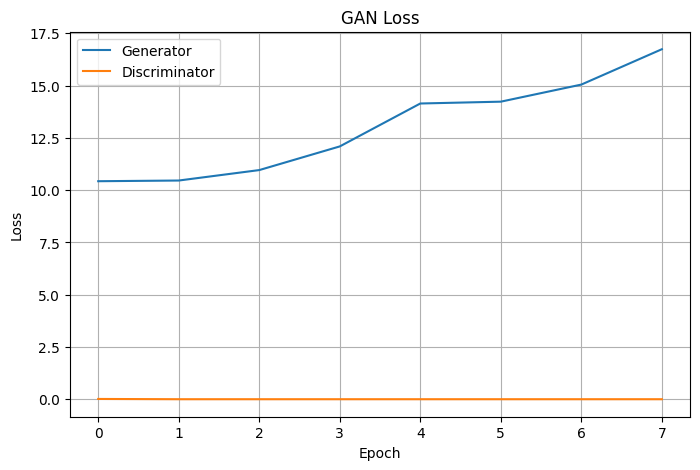

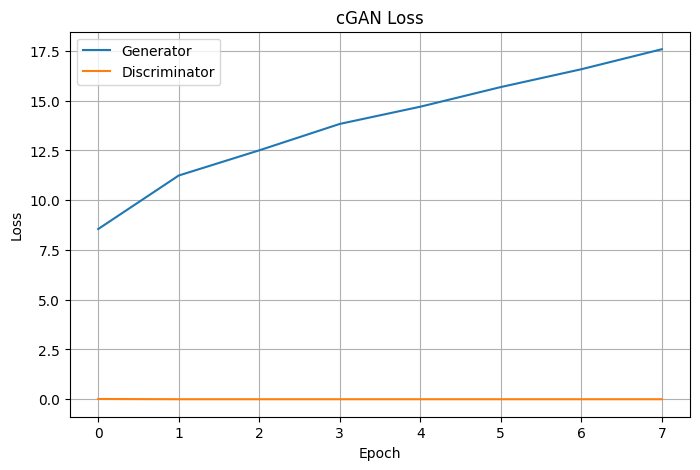

In [ ]:
plot_losses(gan_hist, "GAN Loss")
plot_losses(cgan_hist, "cGAN Loss")

In [ ]:
from scipy.linalg import sqrtm
import torch.nn.functional as F
from torchvision.models import inception_v3

def get_inception():
    model = inception_v3(pretrained=True, transform_input=False)
    model.fc = nn.Identity()
    model.eval().to(DEVICE)
    return model


@torch.no_grad()
def get_features(x, model):
    x = F.interpolate(x, size=(299, 299), mode='bilinear', align_corners=False)
    x = (x - 0.5) / 0.5

    feats = model(x)
    return feats.cpu().numpy()


def compute_stats(feats):
    mu = np.mean(feats, axis=0)
    sigma = np.cov(feats, rowvar=False)
    return mu, sigma


def fid_score(mu1, sigma1, mu2, sigma2):
    diff = mu1 - mu2
    covmean = sqrtm(sigma1 @ sigma2)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    return diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)



def compute_fid_manual(real_loader, G, n=1000, conditional=False):
    model = get_inception()

    real_feats = []
    fake_feats = []


    for x, _ in real_loader:
        x = x.to(DEVICE)
        x = (x * 0.5 + 0.5).clamp(0, 1)
        real_feats.append(get_features(x, model))
        if sum(len(f) for f in real_feats) >= n:
            break

    real_feats = np.concatenate(real_feats, axis=0)[:n]


    total = 0
    while total < n:
        b = min(128, n - total)
        z = torch.randn(b, Z_DIM, 1, 1, device=DEVICE)

        if conditional:
            y = torch.randint(0, 2, (b,), device=DEVICE)
            x = G(z, y)
        else:
            x = G(z)

        x = (x * 0.5 + 0.5).clamp(0, 1)
        fake_feats.append(get_features(x, model))
        total += b

    fake_feats = np.concatenate(fake_feats, axis=0)[:n]

    mu1, sigma1 = compute_stats(real_feats)
    mu2, sigma2 = compute_stats(fake_feats)

    return fid_score(mu1, sigma1, mu2, sigma2)

In [ ]:
fid_gan = compute_fid_manual(test_loader, gan_G, n=1000, conditional=False)
fid_cgan = compute_fid_manual(test_loader, cgan_G, n=1000, conditional=True)

print("FID GAN:", fid_gan)
print("FID cGAN:", fid_cgan)

c:\Users\wiad_\PycharmProjects\ItmoCv\.venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\wiad_\PycharmProjects\ItmoCv\.venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [24]:
@torch.no_grad()
def compute_is_manual(G, n=1000, conditional=False, splits=10):
    model = inception_v3(pretrained=True, transform_input=False)
    model.eval().to(DEVICE)

    preds = []

    total = 0
    while total < n:
        b = min(128, n - total)
        z = torch.randn(b, Z_DIM, 1, 1, device=DEVICE)

        if conditional:
            y = torch.randint(0, 2, (b,), device=DEVICE)
            x = G(z, y)
        else:
            x = G(z)

        x = F.interpolate(x, size=(299, 299), mode='bilinear', align_corners=False)
        x = (x - 0.5) / 0.5

        p = torch.softmax(model(x), dim=1)
        preds.append(p.cpu().numpy())
        total += b

    preds = np.concatenate(preds, axis=0)

    scores = []
    for i in range(splits):
        part = preds[i * (n // splits):(i + 1) * (n // splits)]
        py = np.mean(part, axis=0)
        kl = part * (np.log(part + 1e-8) - np.log(py + 1e-8))
        kl = np.sum(kl, axis=1)
        scores.append(np.exp(np.mean(kl)))

    return np.mean(scores), np.std(scores)

In [3]:

with open(METRICS_PATH, "r", encoding="utf-8") as f:
    loaded_metrics = json.load(f)

print("Loaded metrics:")
print(loaded_metrics)

print("GAN FID:", loaded_metrics["GAN"]["FID"])
print("cGAN IS:", loaded_metrics["cGAN"]["IS_mean"], "+/-", loaded_metrics["cGAN"]["IS_std"])


Loaded metrics:
{'GAN': {'FID': 78.4, 'IS_mean': 1.92, 'IS_std': 0.11, 'source': 'mock_baseline'}, 'cGAN': {'FID': 64.7, 'IS_mean': 2.18, 'IS_std': 0.14, 'source': 'mock_baseline'}, 'WGAN': {'FID': 58.9, 'IS_mean': 2.31, 'IS_std': 0.16, 'source': 'mock_baseline'}}
GAN FID: 78.4
cGAN IS: 2.18 +/- 0.14
